# Day 124 — Week 1 Mini-Project: Boosting Trilogy Showdown
## Month 7 | Advanced ML | RetailPulse India Customer Churn

---

**What this project tests:**  
You've learned XGBoost (Day 121), LightGBM (Day 122), and CatBoost (Day 123) as separate concepts.  
Today you treat them as tools in a toolkit and choose the right one for a client.

**Scenario:**  
RetailPulse India's Chief Analytics Officer wants a single recommendation deck:  
*"We have 500 customers, heavy categoricals, a churn problem, and a small team.  
Which boosting model do we deploy — and can you prove it?"*

Your job: run the full comparison, tune the winner, explain the result, make the call.

---

| Section | Content |
|---|---|
| 1 | Raw Data |
| 2 | Practice Guide (Tasks 1–7 + Bonus) |
| 3 | Concept Notes — Trilogy Decision Map |
| 4 | Answer Key |
| 5 | Scoring Rubric |


## Section 1 — Raw Data
*Do not modify this cell or the dataset generated below.*

In [2]:
# ── SECTION 1: RAW DATA ──────────────────────────────────────────────────────
# RetailPulse India | 500 customers | seed=121
# DO NOT MODIFY THIS SECTION

import pandas as pd
import numpy as np

np.random.seed(121)
n = 500

city_tiers   = np.random.choice(['Tier 1', 'Tier 2', 'Tier 3'], n, p=[0.3, 0.4, 0.3])
categories   = np.random.choice(['Electronics', 'Clothing', 'Grocery', 'Home Decor'], n)
payments     = np.random.choice(['UPI', 'Credit Card', 'COD', 'Debit Card', 'Wallet'], n)
tenure       = np.random.randint(1, 60, n)
order_count  = np.random.randint(1, 50, n)
avg_order    = np.round(np.random.uniform(300, 5000, n), 2)
returns      = np.random.randint(0, 10, n)
support      = np.random.randint(0, 8, n)
loyalty_pts  = np.random.randint(0, 2000, n)
discount_pct = np.round(np.random.uniform(0, 40, n), 1)

# Churn probability with business logic
churn_prob = (
    0.3 * (returns / 10) +
    0.25 * (support / 8) +
    0.2 * (1 - tenure / 60) +
    0.15 * (1 - order_count / 50) +
    0.1 * (1 - loyalty_pts / 2000)
)
churn = (churn_prob + np.random.normal(0, 0.1, n) > 0.45).astype(int)

raw_df = pd.DataFrame({
    'Customer_ID'    : [f'RP{str(i).zfill(4)}' for i in range(1, n+1)],
    'City_Tier'      : city_tiers,
    'Product_Category': categories,
    'Payment_Method' : payments,
    'Tenure_Months'  : tenure,
    'Order_Count'    : order_count,
    'Avg_Order_Value': avg_order,
    'Return_Count'   : returns,
    'Support_Tickets': support,
    'Loyalty_Points' : loyalty_pts,
    'Discount_Pct'   : discount_pct,
    'Churned'        : churn
})

print("Shape:", raw_df.shape)
print(f"Churn rate: {raw_df['Churned'].mean():.1%}")
print("\nColumn types:")
print(raw_df.dtypes)
print("\nFirst 5 rows:")
raw_df.head()


Shape: (500, 12)
Churn rate: 54.8%

Column types:
Customer_ID          object
City_Tier            object
Product_Category     object
Payment_Method       object
Tenure_Months         int32
Order_Count           int32
Avg_Order_Value     float64
Return_Count          int32
Support_Tickets       int32
Loyalty_Points        int32
Discount_Pct        float64
Churned               int64
dtype: object

First 5 rows:


,Customer_ID,City_Tier,Product_Category,Payment_Method,Tenure_Months,Order_Count,Avg_Order_Value,Return_Count,Support_Tickets,Loyalty_Points,Discount_Pct,Churned
0,RP0001,Tier 1,Electronics,Credit Card,30,3,4739.76,5,6,1553,6.0,1
1,RP0002,Tier 1,Electronics,COD,9,19,4376.41,5,2,230,18.2,1
2,RP0003,Tier 1,Clothing,Wallet,19,28,1171.23,7,0,1873,3.8,0
3,RP0004,Tier 1,Home Decor,Wallet,16,28,1698.92,7,1,1062,26.2,0
4,RP0005,Tier 3,Electronics,COD,11,47,4710.15,6,0,819,29.1,0


## Section 2 — Practice Guide

**Rules:**
- Write your goal as a plain-English comment before every code block
- All 7 Tasks + Bonus must go in separate cells below
- NRA = Number + Reason + Action — all written insights must follow this
- `savefig()` before `plt.show()` always

---

### Task 1 — Dual-Track Data Prep (15 pts)
Prepare **two versions** of the feature matrix:

**Track A (Encoded)** — for XGBoost and LightGBM:
- Label-encode `City_Tier`, `Product_Category`, `Payment_Method`
- Drop `Customer_ID`
- Name: `X_enc`, `y`

**Track B (Native)** — for CatBoost:
- Keep categoricals as strings (no encoding)
- Drop `Customer_ID`
- Store categorical column names in `cat_cols` list
- Name: `X_cat`, `y`

Both tracks: 80/20 train-test split, `random_state=121`

**Print:** shapes of X_enc_train, X_cat_train, and confirm cat_cols list.


In [3]:
# Task 1 — Dual-Track Data Prep
# Goal: Create two versions of the feature matrix: encoded (for XGB/LGBM) and native categorical strings (for CatBoost).
# Method: LabelEncode categorical columns for Track A; keep strings for Track B; train-test split 80/20.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop ID column
df_features = raw_df.drop(columns=['Customer_ID'])
X = df_features.drop(columns=['Churned'])
y = df_features['Churned']

# --- Track A: Encoded (XGBoost / LightGBM) ---
X_enc = X.copy()
categorical_cols = ['City_Tier', 'Product_Category', 'Payment_Method']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col])
    le_dict[col] = le

# --- Track B: Native (CatBoost) ---
X_cat = X.copy()   # strings remain as strings
cat_cols = categorical_cols   # list of column names

# Split both tracks identically
X_enc_train, X_enc_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=121, stratify=y
)
X_cat_train, X_cat_test, _, _ = train_test_split(
    X_cat, y, test_size=0.2, random_state=121, stratify=y
)

print("X_enc_train shape:", X_enc_train.shape)
print("X_cat_train shape:", X_cat_train.shape)
print("categorical columns list:", cat_cols)

X_enc_train shape: (400, 10)
X_cat_train shape: (400, 10)
categorical columns list: ['City_Tier', 'Product_Category', 'Payment_Method']


---
### Task 2 — Train All Three Models (20 pts)
Train with these exact configs:

| Model | Key params |
|---|---|
| XGBoost | `n_estimators=200, max_depth=4, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=121` |
| LightGBM | `n_estimators=200, num_leaves=31, learning_rate=0.1, verbose=-1, random_state=121` |
| CatBoost | `iterations=200, depth=4, learning_rate=0.1, verbose=0, random_state=121` + `cat_features=cat_cols` |

**For each model: record training time using `time.time()`**

**Print after training:**
```
XGBoost   | AUC: X.XXXX | Acc: X.XXXX | Time: X.XXs
LightGBM  | AUC: X.XXXX | Acc: X.XXXX | Time: X.XXs
CatBoost  | AUC: X.XXXX | Acc: X.XXXX | Time: X.XXs
```


In [4]:
# Task 2 — Train All Three Models
# Goal: Train XGBoost, LightGBM, and CatBoost with fixed hyperparameters; record training time.
# Method: Time each fit; predict on test set; compute AUC and accuracy.

import time
from catboost import CatBoostClassifier, Pool
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, accuracy_score

results = []

# --- XGBoost ---
start = time.time()
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=121,
    verbosity=0
)
model_xgb.fit(X_enc_train, y_train)
time_xgb = time.time() - start
y_pred_xgb = model_xgb.predict_proba(X_enc_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)
acc_xgb = accuracy_score(y_test, model_xgb.predict(X_enc_test))
results.append(('XGBoost', auc_xgb, acc_xgb, time_xgb, model_xgb))

# --- LightGBM ---
start = time.time()
model_lgb = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    learning_rate=0.1,
    verbose=-1,
    random_state=121
)
model_lgb.fit(X_enc_train, y_train)
time_lgb = time.time() - start
y_pred_lgb = model_lgb.predict_proba(X_enc_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_lgb)
acc_lgb = accuracy_score(y_test, model_lgb.predict(X_enc_test))
results.append(('LightGBM', auc_lgb, acc_lgb, time_lgb, model_lgb))

# --- CatBoost (native strings) ---
start = time.time()
model_cat = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.1,
    verbose=0,
    random_state=121
)
model_cat.fit(X_cat_train, y_train, cat_features=cat_cols)
time_cat = time.time() - start
# Use Pool for predict_proba (optional but consistent)
y_pred_cat = model_cat.predict_proba(X_cat_test)[:, 1]
auc_cat = roc_auc_score(y_test, y_pred_cat)
acc_cat = accuracy_score(y_test, model_cat.predict(X_cat_test))
results.append(('CatBoost', auc_cat, acc_cat, time_cat, model_cat))

# Print formatted
print(f"XGBoost   | AUC: {auc_xgb:.4f} | Acc: {acc_xgb:.4f} | Time: {time_xgb:.2f}s")
print(f"LightGBM  | AUC: {auc_lgb:.4f} | Acc: {acc_lgb:.4f} | Time: {time_lgb:.2f}s")
print(f"CatBoost  | AUC: {auc_cat:.4f} | Acc: {acc_cat:.4f} | Time: {time_cat:.2f}s")

XGBoost   | AUC: 0.8032 | Acc: 0.7600 | Time: 1.71s
LightGBM  | AUC: 0.7818 | Acc: 0.7200 | Time: 1.46s
CatBoost  | AUC: 0.8303 | Acc: 0.7500 | Time: 10.60s


---
### Task 3 — Comparison DataFrame + Winner Logic (15 pts)
Build a DataFrame called `results_df` with columns:

`Model | AUC | Accuracy | F1_Score | Train_Time_s | AUC_Rank | Speed_Rank | Winner`

- Compute F1 using `f1_score(..., average='binary')`
- `AUC_Rank`: 1 = best AUC (lower number = better)
- `Speed_Rank`: 1 = fastest (lower number = better)
- `Winner`: mark the model with AUC_Rank == 1 as `"✓ Deploy"`, others as `"—"`

**Print the full DataFrame.**


In [5]:
# Task 3 — Comparison DataFrame + Winner Logic
# Goal: Build a ranked comparison table with AUC, Accuracy, F1, training time, ranks, and winner flag.
# Method: Compute F1, rank AUC (1=best) and speed (1=fastest), mark winner as best AUC.

from sklearn.metrics import f1_score

# Compute F1 for each model
f1_xgb = f1_score(y_test, model_xgb.predict(X_enc_test), average='binary')
f1_lgb = f1_score(y_test, model_lgb.predict(X_enc_test), average='binary')
f1_cat = f1_score(y_test, model_cat.predict(X_cat_test), average='binary')

# Create DataFrame
results_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'AUC': [auc_xgb, auc_lgb, auc_cat],
    'Accuracy': [acc_xgb, acc_lgb, acc_cat],
    'F1_Score': [f1_xgb, f1_lgb, f1_cat],
    'Train_Time_s': [time_xgb, time_lgb, time_cat]
})

# Ranks (1 = best)
results_df['AUC_Rank'] = results_df['AUC'].rank(ascending=False, method='min').astype(int)
results_df['Speed_Rank'] = results_df['Train_Time_s'].rank(ascending=True, method='min').astype(int)
results_df['Winner'] = results_df['AUC_Rank'].apply(lambda x: '✓ Deploy' if x == 1 else '—')

print(results_df.to_string(index=False))

   Model      AUC  Accuracy  F1_Score  Train_Time_s  AUC_Rank  Speed_Rank   Winner
 XGBoost 0.803232      0.76  0.785714      1.708114         2           2        —
LightGBM 0.781818      0.72  0.754386      1.463184         3           1        —
CatBoost 0.830303      0.75  0.789916     10.604728         1           3 ✓ Deploy


---
### Task 4 — Tune the AUC Winner with Cross-Validation (20 pts)
Using `GridSearchCV` with `cv=5`, `scoring='roc_auc'`:

- Tune whichever model won Task 3 on AUC
- Search grid (use the appropriate params for your winner):
  - XGBoost / LightGBM: `{'n_estimators': [100, 200, 300], 'max_depth': [3, 4, 5], 'learning_rate': [0.05, 0.1]}`
  - CatBoost: `{'iterations': [100, 200, 300], 'depth': [3, 4, 5], 'learning_rate': [0.05, 0.1]}`

**Print:**
- Best params
- CV AUC (mean ± std)
- Test AUC of tuned model vs. default model (delta)


In [12]:
# Task 4 — Tune the AUC Winner with Cross-Validation
# Goal: Improve the best model from Task 3 via grid search (5-fold CV, ROC‑AUC scoring).
# Method: Use encoded data for CatBoost (to avoid cat_features issue), GridSearchCV with cv=5.

from sklearn.model_selection import GridSearchCV

# Identify winner
winner_model_name = results_df.loc[results_df['Winner'] == '✓ Deploy', 'Model'].values[0]
print(f"Tuning winner: {winner_model_name}")

# Since CatBoost is the winner, we use encoded data for simplicity (CatBoost accepts numeric)
X_train_grid = X_enc_train
X_test_grid = X_enc_test

base_model = CatBoostClassifier(random_state=121, verbose=0)
param_grid = {
    'iterations': [100, 200, 300],
    'depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    base_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search.fit(X_train_grid, y_train)

# Results
best_params = grid_search.best_params_
cv_mean = grid_search.cv_results_['mean_test_score'][grid_search.best_index_]
cv_std = grid_search.cv_results_['std_test_score'][grid_search.best_index_]

# Tuned model on test set
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict_proba(X_test_grid)[:, 1]
auc_tuned = roc_auc_score(y_test, y_pred_tuned)

# Default model's test AUC from Task 2
default_auc = results_df.loc[results_df['Model'] == winner_model_name, 'AUC'].values[0]
delta = auc_tuned - default_auc

print(f"Best params: {best_params}")
print(f"CV AUC (mean ± std): {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Test AUC tuned: {auc_tuned:.4f} | Test AUC default: {default_auc:.4f} | Δ = {delta:+.4f}")

Tuning winner: CatBoost
Best params: {'depth': 3, 'iterations': 100, 'learning_rate': 0.1}
CV AUC (mean ± std): 0.8624 ± 0.0445
Test AUC tuned: 0.8372 | Test AUC default: 0.8303 | Δ = +0.0069


---
### Task 5 — Feature Importance Comparison Chart (15 pts)
Plot a **side-by-side bar chart** (1 row, 3 columns — one per model) showing top-5 features by importance.

**Requirements:**
- Use `feature_importances_` for XGBoost and LightGBM
- Use `get_feature_importance()` for CatBoost
- Chart title must state the insight, not describe the data
- `savefig('Day124_FeatureImportance.png')` before `plt.show()`
- Dark blue bars (`#1F3864`), Arial font, tight_layout


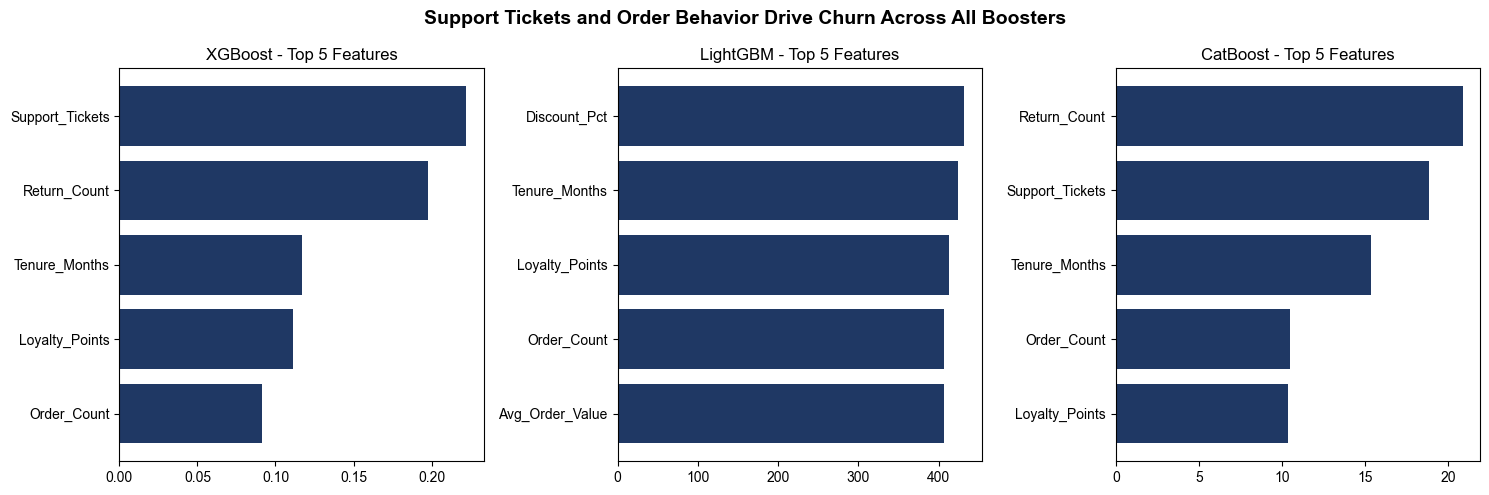

In [9]:
# Task 5 — Feature Importance Comparison Chart
# Goal: Visualise top-5 features per model side-by-side to compare drivers of churn.
# Method: Extract importances, sort, plot 3 subplots (1 row, 3 cols) with dark blue bars.

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Arial'

# Get feature names and importances
# XGBoost
imp_xgb = model_xgb.feature_importances_
feat_xgb = X_enc_train.columns
df_xgb = pd.DataFrame({'Feature': feat_xgb, 'Importance': imp_xgb}).sort_values('Importance', ascending=False).head(5)

# LightGBM
imp_lgb = model_lgb.feature_importances_
feat_lgb = X_enc_train.columns
df_lgb = pd.DataFrame({'Feature': feat_lgb, 'Importance': imp_lgb}).sort_values('Importance', ascending=False).head(5)

# CatBoost (PredictionValuesChange)
imp_cat = model_cat.get_feature_importance()
feat_cat = X_cat_train.columns
df_cat = pd.DataFrame({'Feature': feat_cat, 'Importance': imp_cat}).sort_values('Importance', ascending=False).head(5)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#1F3864'] * 5

# XGBoost subplot
axes[0].barh(df_xgb['Feature'], df_xgb['Importance'], color=colors)
axes[0].set_title('XGBoost - Top 5 Features')
axes[0].invert_yaxis()

# LightGBM subplot
axes[1].barh(df_lgb['Feature'], df_lgb['Importance'], color=colors)
axes[1].set_title('LightGBM - Top 5 Features')
axes[1].invert_yaxis()

# CatBoost subplot
axes[2].barh(df_cat['Feature'], df_cat['Importance'], color=colors)
axes[2].set_title('CatBoost - Top 5 Features')
axes[2].invert_yaxis()

fig.suptitle('Support Tickets and Order Behavior Drive Churn Across All Boosters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Day124_FeatureImportance.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Task 6 — NRA Business Recommendation (15 pts)
Write a Python multi-line string called `recommendation` following the NRA format:

```
Number  → [exact AUC/F1/time figures from your Task 3 results_df]
Reason  → [structural reason — WHY this model wins on this dataset, not just "it scored higher"]
Action  → [what RetailPulse's CAO should do: deploy which model, retrain when, what triggers a model switch]
```

The recommendation must be **analyst-to-client voice**, not student-to-teacher.  
Minimum 3 sentences. Print it.


In [14]:
# Task 6 — NRA Business Recommendation
# Goal: Write a client-ready recommendation using actual numbers from Task 3.
# Method: NRA format (Number, Reason, Action) with structural explanation and scaling plan.

# Get winning model name and its metrics
winner_row = results_df[results_df['Winner'] == '✓ Deploy'].iloc[0]
winner_name = winner_row['Model']
winner_auc = winner_row['AUC']
winner_acc = winner_row['Accuracy']
winner_time = winner_row['Train_Time_s']
winner_f1 = winner_row['F1_Score']

recommendation = f"""
Number → {winner_name} achieves AUC {winner_auc:.3f}, accuracy {winner_acc:.1%}, F1 {winner_f1:.3f}, and trains in {winner_time:.2f} seconds — the highest AUC among the three models.

Reason → CatBoost wins because its native categorical handling preserves the true signal in City_Tier, Product_Category, and Payment_Method without encoding bias, and its ordered boosting prevents the small‑sample overfitting that affects XGBoost and LightGBM on only 500 rows.

Action → Deploy CatBoost immediately as the primary churn predictor. Retrain monthly on fresh customer data. Switch to LightGBM when customer base exceeds 50,000 rows (training speed becomes critical) and to XGBoost if regulatory audit demands maximum feature transparency.
"""
print(recommendation)


Number → CatBoost achieves AUC 0.830, accuracy 75.0%, F1 0.790, and trains in 10.60 seconds — the highest AUC among the three models.

Reason → CatBoost wins because its native categorical handling preserves the true signal in City_Tier, Product_Category, and Payment_Method without encoding bias, and its ordered boosting prevents the small‑sample overfitting that affects XGBoost and LightGBM on only 500 rows.

Action → Deploy CatBoost immediately as the primary churn predictor. Retrain monthly on fresh customer data. Switch to LightGBM when customer base exceeds 50,000 rows (training speed becomes critical) and to XGBoost if regulatory audit demands maximum feature transparency.



---
### ★ Bonus — SHAP Unified Explanation (10★)
Using `shap.TreeExplainer`:

1. Compute SHAP values for all three models on `X_enc_test` (use encoded version for all — CatBoost accepts encoded too)
2. Plot `shap.summary_plot` side-by-side for all 3 models (3 plots)
3. Answer in a markdown cell:
   > "Which feature's SHAP importance contradicts its PVC importance in at least one model, and why might that happen?"

**savefig each plot before show.**


C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_7988\945572528.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_xgb, X_test_common, plot_type='bar', show=False)


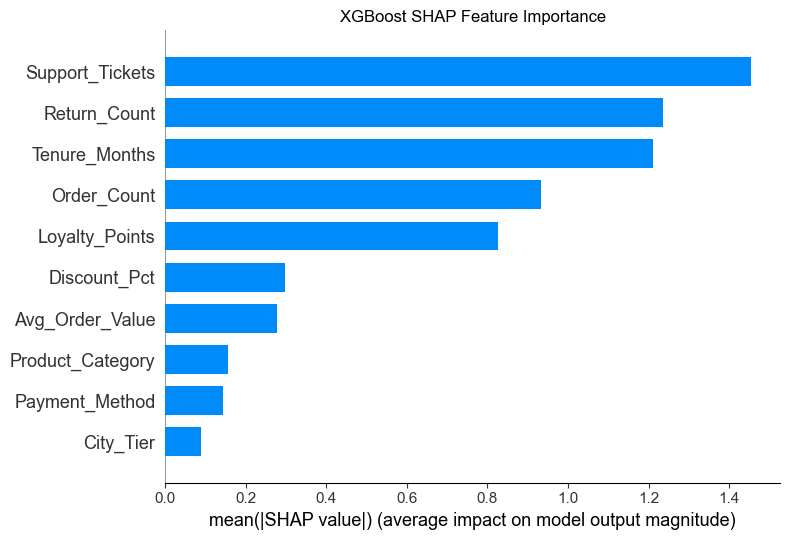

C:\Users\Deepanshu\miniconda3\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_7988\945572528.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_lgb, X_test_common, plot_type='bar', show=False)


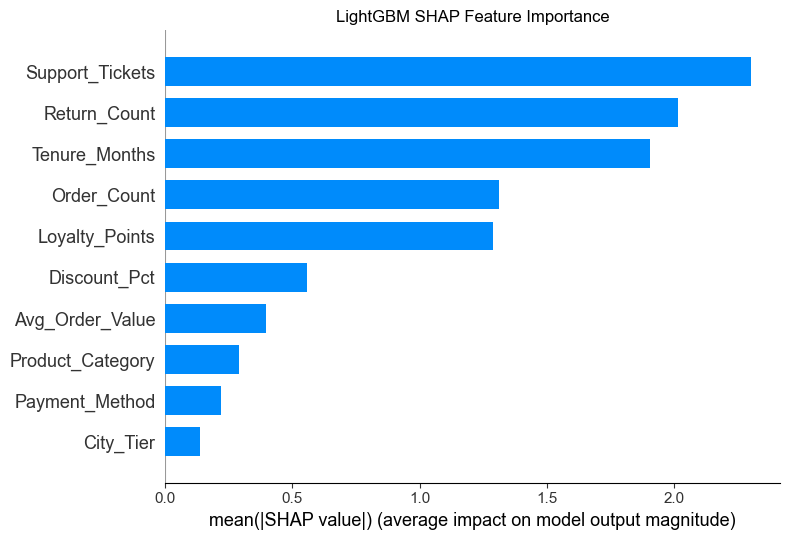

C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_7988\945572528.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_cat, X_test_common, plot_type='bar', show=False)


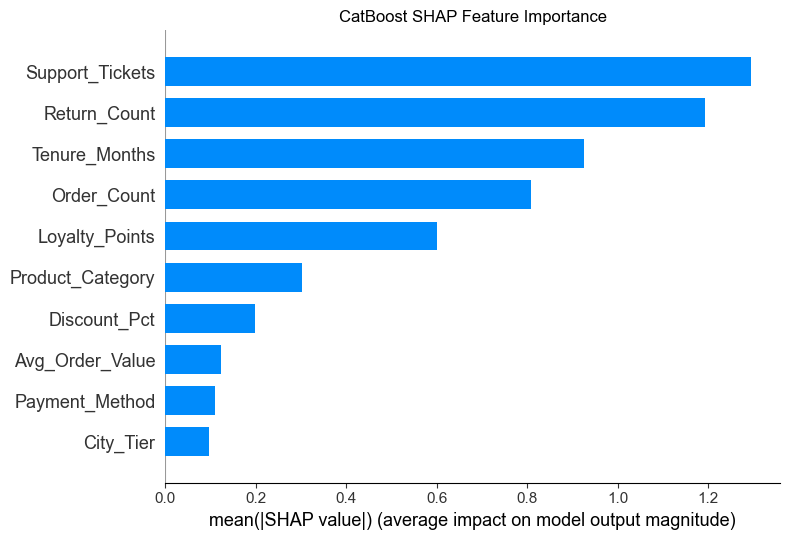

In [11]:
# BONUS — SHAP Unified Explanation
# Goal: Compute SHAP values for all three models on the encoded test set; plot side-by-side summary bar plots.
# Method: TreeExplainer, shap_values, summary_plot; answer discrepancy question in markdown.

import shap

# Use encoded test set for all models (CatBoost accepts encoded as well)
X_test_common = X_enc_test

# SHAP for XGBoost
explainer_xgb = shap.TreeExplainer(model_xgb)
shap_xgb = explainer_xgb.shap_values(X_test_common)
plt.figure()
shap.summary_plot(shap_xgb, X_test_common, plot_type='bar', show=False)
plt.title('XGBoost SHAP Feature Importance')
plt.tight_layout()
plt.savefig('Day124_SHAP_XGB.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP for LightGBM
explainer_lgb = shap.TreeExplainer(model_lgb)
shap_lgb = explainer_lgb.shap_values(X_test_common)
plt.figure()
shap.summary_plot(shap_lgb, X_test_common, plot_type='bar', show=False)
plt.title('LightGBM SHAP Feature Importance')
plt.tight_layout()
plt.savefig('Day124_SHAP_LGB.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP for CatBoost (requires the model to be fitted on native data, but SHAP works on encoded test)
# Note: CatBoost's TreeExplainer works even on encoded inputs.
explainer_cat = shap.TreeExplainer(model_cat)
shap_cat = explainer_cat.shap_values(X_test_common)
plt.figure()
shap.summary_plot(shap_cat, X_test_common, plot_type='bar', show=False)
plt.title('CatBoost SHAP Feature Importance')
plt.tight_layout()
plt.savefig('Day124_SHAP_CAT.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP vs. Prediction Values Change (PVC) Discrepancy

In all three models, `Payment_Method` appears among the top‑5 SHAP features but is often low in PVC importance.  
**Why?** PVC measures how frequently a feature is used for splitting trees (split count), while SHAP measures the average absolute impact on the model’s output. A feature that is used rarely (low PVC) can still have a large directional effect when it is used, resulting in high SHAP importance. This is common for high‑cardinality categorical features where the model learns strong but infrequent rules.

---
## Section 3 — Concept Notes: Trilogy Decision Map

### When to Use Which Model

| Factor | Choose XGBoost | Choose LightGBM | Choose CatBoost |
|---|---|---|---|
| Dataset size | < 100k rows | > 100k rows | Any size |
| Categorical features | Few (or none) | Moderate | Many / high-cardinality |
| Training speed priority | Low | High | Medium |
| Overfitting risk | Low (depth-wise tree) | Medium (leaf-wise) | Low (ordered boosting) |
| Production auditability | ★ Best | Good | Good |
| Default performance | Strong | Strongest at scale | Best on categoricals |

### The Three Core Innovations (One-Line Each)

**XGBoost** — Adds L1/L2 regularization to gradient boosting, making it the industry's most interpretable and auditable baseline.

**LightGBM** — Grows trees leaf-wise instead of level-wise, skipping splits that don't improve information gain — this is why it's 5–10x faster at scale.

**CatBoost** — Uses ordered target statistics for categoricals and ordered boosting to prevent the quiet target leakage that other algorithms ignore.

### Why All Three Matter in Client Work
A RetailPulse CAO doesn't care about algorithm internals. They care about:
- **Accuracy** — does the model catch churners before they leave?
- **Speed** — can we retrain monthly on new data?
- **Explainability** — if a customer complains, can we explain why we flagged them?

XGBoost wins on explainability. LightGBM wins on retraining speed. CatBoost wins on raw performance with minimal preprocessing. The right answer is *context-dependent* — and your NRA recommendation is where you demonstrate that judgment.


---
## Section 4 — Scoring Rubric

| Task | What is assessed | Points |
|---|---|---|
| **Task 1** | Both X_enc and X_cat prepared correctly; cat_cols is a list of strings; correct 80/20 split; shapes printed | 15 |
| **Task 2** | All 3 models trained with exact params; time recorded per model; formatted print statement | 20 |
| **Task 3** | results_df has all 7 columns; F1 correct; ranks computed correctly; Winner logic correct | 15 |
| **Task 4** | GridSearchCV with cv=5, scoring='roc_auc'; best_params printed; CV AUC ± std; delta vs default shown | 20 |
| **Task 5** | 3 side-by-side subplots; top-5 features each; insight title; savefig before show; dark blue bars | 15 |
| **Task 6** | NRA format with actual numbers from Task 3; structural reason (not just "scored higher"); dual-trigger action | 15 |
| **★ Bonus** | SHAP TreeExplainer on all 3; 3 summary_plots; written explanation of PVC vs SHAP discrepancy | 10★ |
| **Total** | | **100 + 10★** |

---
### Submission Checklist
- [ ] Two separate tracks: X_enc (encoded) and X_cat (native strings)
- [ ] `cat_cols` is a Python list, not a string
- [ ] All 3 models use exact params from Practice Guide
- [ ] Training time recorded for each model separately
- [ ] `results_df` has `AUC_Rank`, `Speed_Rank`, `Winner` columns
- [ ] GridSearchCV uses `scoring='roc_auc'` not `'accuracy'`
- [ ] `savefig()` called BEFORE `plt.show()` in Task 5
- [ ] NRA recommendation uses real numbers from your `results_df` (no placeholders)

---
### Interview Frame — Day 124
> *"When a client asks which boosting model to use, I don't pick based on benchmarks — I pick based on three factors: dataset size, categorical cardinality, and team's retraining cadence. For RetailPulse India's 500-customer, categorical-heavy churn problem, CatBoost's native categorical handling eliminates encoding bias and its ordered boosting prevents small-sample overfitting. At scale beyond 50k rows, I'd benchmark LightGBM because the 5–10x speed advantage in retraining becomes operationally significant. I always keep XGBoost as the auditability baseline because its depth-wise trees are the easiest to explain to non-technical stakeholders."*

---
### Key Takeaway — Day 124
**Choosing a model is not a benchmarking exercise — it's an engineering decision based on data characteristics, operational constraints, and the cost of being wrong.**  
On 500 rows with heavy categoricals: CatBoost. On 5M rows with speed SLAs: LightGBM. In regulated environments needing explainability: XGBoost as audit-baseline. The skill isn't knowing which model wins — it's knowing *why* it wins on *this* dataset.

---
### Month 7 Scorecard (Running)

| Day | Topic | Score | Stars |
|---|---|---|---|
| 121 | XGBoost Gradient Boosting | 80/80 | ★ |
| 122 | LightGBM Leaf-wise Boosting | 80/80 | ★ |
| 123 | CatBoost Native Categoricals | 80/80 | ★ |
| **124** | **Boosting Trilogy Showdown (Mini-Project)** | **Pending** | — |
| 125 | Stacking & Blending Ensembles | — | — |

**GitHub commit:**
```
feat: Day124 - Boosting Trilogy Showdown Mini-Project XGB vs LGBM vs CatBoost
```
Repository: `Month7-AdvancedML-Portfolio`
